### Climate Data source - GridMET Data aquired from https://www.climatologylab.org/wget-gridmet.html  
Variables to process: 
1. etr (Reference alfalfa evaportranspiration)
2. FM100 (100-hour dead fuel moisture)
3. pet (Reference grass evaportranspiration)
4. pr (Precipitation)
5. sph (Near-Surface Specific Humidity)
6. srad (Surface Downwelling Solar Radiation)
7. th (Wind direction at 10 m)
8. tmmx (Maximum Near-Surface Air Temperature)
9. vpd (Mean Vapor Pressure Deficit)
10. vs (Wind speed at 10 m)

https://portal.nccs.nasa.gov/datashare/GlobalFWI/ (Link to download Fire Weather Index data)

In [ ]:
# from dask.distributed import Client
# client = Client(memory_limit='30GB')

# print(client)

<Client: 'tcp://127.0.0.1:64325' processes=4 threads=8, memory=63.01 GiB>


In [1]:
import os, glob
import pandas as pd
import xarray as xr
import geopandas as gpd
import rioxarray
from rasterstats import zonal_stats
import numpy as np

In [ ]:
# #Clustering the yearly files into one for each variable
# varlist = ['etr', 'fm100','pet','pr','sph','srad','th','tmmx','vpd','vs','pdsi']
# path = 'D:\Self projects\Wildfire risk assessment\Climate data\*.nc'
# matches = [[file for file in glob.glob(path) if var in file] for var in varlist]


In [ ]:
# for i in matches:
#     xr.open_mfdataset(i,combine = 'by_coords').to_netcdf(f"D:\Self projects\Wildfire risk assessment\Climate data\{varlist[matches.index(i)]}.nc")

In [ ]:
# #Clipping DEM file to CA region
# dem_us = xr.open_dataset(r"C:\Users\pranj\Downloads\metdata_elevationdata.nc")
# states_shapefile_url = 'https://firms.modaps.eosdis.nasa.gov/content/notebooks/exampleStatesShapefile2023(20m:coarse).zip'
# ca = gpd.read_file(states_shapefile_url)
# ca = ca[ca['NAME']=='California']
# ca = ca.to_crs(epsg=4326)
# dem_us.rio.write_crs(ca.crs, inplace=True)
# clipped_data = dem_us.rio.clip(ca.geometry.values, ca.crs, all_touched=True)
# clipped_data.to_netcdf(r"D:\Self projects\Wildfire risk assessment\Feature datasets\DEM_CA.nc")

In [2]:
%store -r fire_lulc_dissolved

In [3]:
#Opening climate data files
path = r"Climate data"
climvars = os.listdir(path)[2:]
l = []
for file in os.listdir(os.path.join(path,climvars[8])): #change here
    f= xr.open_dataset(os.path.join(path,climvars[8],file)) #change here
    for var in f.data_vars:
        if f[var].dtype in ['float64','int64']:
            f[var] = f[var].astype("float32")
    l.append(f)
    # f.to_zarr(os.path.join("Climate data\Consolidated files",file[:-3]+".zarr"))

In [4]:
f

<xarray.Dataset> Size: 83MB
Dimensions:      (lon: 247, lat: 229, day: 366)
Coordinates:
  * lon          (lon) float64 2kB -124.4 -124.3 -124.3 ... -114.2 -114.2 -114.1
  * lat          (lat) float64 2kB 42.03 41.98 41.94 41.9 ... 32.61 32.57 32.53
  * day          (day) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
    spatial_ref  int64 8B ...
Data variables:
    crs          float32 4B 0.0
    wind_speed   (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 March 2021
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [ ]:
# climdata = {file.split('.')[0]:l[climvars.index(file)] for file in climvars}

In [ ]:
# climdata.keys()
#1. etr (Reference alfalfa evaportranspiration)
#2. FM100 (100-hour dead fuel moisture)
#3. pet (Reference grass evaportranspiration)
#4. pr (Precipitation)
#5. sph (Near-Surface Specific Humidity)
#6. srad (Surface Downwelling Solar Radiation)
#7. th (Wind direction at 10 m)
#8. tmmx (Maximum Near-Surface Air Temperature)
#9. vpd (Mean Vapor Pressure Deficit)
#10. vs (Wind speed at 10 m)


dict_keys(['etr', 'fm100', 'pet', 'pr', 'sph', 'srad', 'th', 'tmmx', 'vpd', 'vs'])

In [6]:
fire_lulc_dissolved['ACQ_DATE'].unique()

<DatetimeArray>
['2001-03-22 00:00:00', '2001-03-27 00:00:00', '2001-04-01 00:00:00',
 '2001-04-04 00:00:00', '2001-04-11 00:00:00', '2001-05-08 00:00:00',
 '2001-05-28 00:00:00', '2001-05-30 00:00:00', '2001-06-13 00:00:00',
 '2001-07-16 00:00:00',
 ...
 '2020-11-03 00:00:00', '2020-11-04 00:00:00', '2020-11-05 00:00:00',
 '2020-11-12 00:00:00', '2020-11-17 00:00:00', '2020-11-18 00:00:00',
 '2020-11-24 00:00:00', '2020-11-25 00:00:00', '2020-11-26 00:00:00',
 '2020-12-03 00:00:00']
Length: 2288, dtype: datetime64[ms]

In [ ]:

# for key in climdata.keys():
#     for i in range(len(lat)):
#         x=lon[i]
#         y=lat[i]
#         climdata[key].sel(lat=y,lon =x,method='nearest').compute()


In [5]:
window_dict = {
    'etr': [2,4,8],'fm100':[1,2,4],'pr':[4,8,12],'sph':[1,2,4],
    'srad':[2,4,8],'th':[1,2,4],'tmmx':[2,4,8],'vpd':[2,4,8],
    'vs':[1,2,4]
    }
for window in window_dict[climvars[8]]: #change here
    var = climvars[8] #change here
    for file in l:
        if var in ['etr','fm100', 'pet','sph', 'srad', 'th','vpd']:
            file[var+str(window)] = file[list(file.data_vars.keys())[1]].rolling(day=window*7).mean()
        elif var in ['tmmx','vs']:
            file[var+str(window)] = file[list(file.data_vars.keys())[1]].rolling(day=window*7).max()
        else:
            file[var+str(window)] = file[list(file.data_vars.keys())[1]].rolling(day=window*7).sum()

In [6]:
l[19]

<xarray.Dataset> Size: 331MB
Dimensions:      (lon: 247, lat: 229, day: 366)
Coordinates:
  * lon          (lon) float64 2kB -124.4 -124.3 -124.3 ... -114.2 -114.2 -114.1
  * lat          (lat) float64 2kB 42.03 41.98 41.94 41.9 ... 32.61 32.57 32.53
  * day          (day) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
    spatial_ref  int64 8B ...
Data variables:
    crs          float32 4B 0.0
    wind_speed   (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs1          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs2          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs4          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       03 March 2021
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

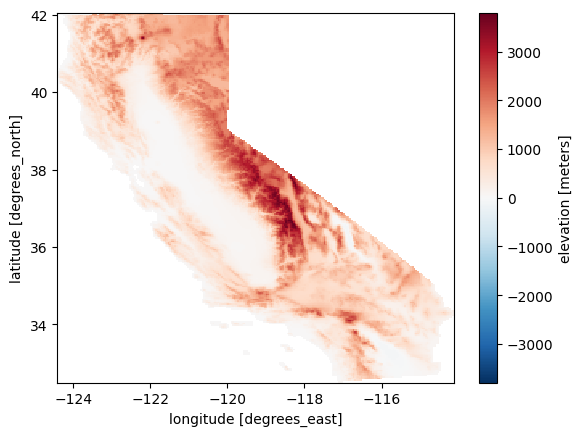

In [11]:
dem_ca = xr.load_dataset(r"D:\Self projects\Wildfire risk assessment\Feature datasets\DEM_CA.nc")['elevation']
dem_ca.plot()

In [12]:
zonal_means = zonal_stats(
        fire_lulc_dissolved,
        dem_ca.values,
        affine=dem_ca.rio.transform(),
        stats=["mean"],
    )

C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\rasterstats\io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [13]:
fire_lulc_dissolved["mean_elev"] = [z["mean"] if z else None for z in zonal_means]

In [14]:
fire_lulc_dissolved.head(3)

,ACQ_DATE,geom_id,geometry,FRP,BRIGHT_T31,label,year,area_sqkm,ordinal date,BurnDate,...,tmmx8,mean_vapor_pressure_deficit,vpd2,vpd4,vpd8,wind_speed,vs1,vs2,vs4,mean_elev
0,2001-03-22,426.0,"POLYGON ((-121.73997 38.92872, -121.74018 38.9...",19.2,299.3,[Pasture/Hay],2001,1.857430,81,80.0,...,300.0,0.87,0.8307143,0.6503572,0.54357135,2.1,2.4,4.0,6.5,7.32
1,2001-03-27,358.0,"POLYGON ((-122.19716 39.1709, -122.19743 39.17...",23.0,299.4,[Pasture/Hay],2001,4.072479,86,87.0,...,300.2,1.12,0.94500005,0.7971429,0.6380358,6.7,6.7,6.7,10.7,NaN
2,2001-04-01,95.0,"POLYGON ((-122.18138 39.5037, -122.18165 39.51...",40.3,305.5,[Developed Low Intensity],2001,2.026472,91,88.0,...,301.6,1.15,1.0957143,0.94714296,0.71267843,2.1,9.2,9.2,11.1,NaN


In [7]:
clim = []
for win in list(l[0].data_vars.keys())[1:]:
    window = []
    yr=2000
    s=-1
    for file in l:
        s=s+1
        yr=yr+1
        f = fire_lulc_dissolved[fire_lulc_dissolved['year']==yr]
        if type(file)!=float:
            if file.day.dt.year[0].values!=yr:
                window.extend([np.nan]*len(f))
                l.insert(s,np.nan)
            else:
                print(file)
                lon = f.to_crs(epsg=3310).geometry.centroid.to_crs(epsg=4326).x
                lat =f.to_crs(epsg=3310).geometry.centroid.to_crs(epsg=4326).y
                for i in range(len(f)):
                    x = lon.iloc[i]
                    y=lat.iloc[i]
                    window.append(file[win].sel(day=f['ACQ_DATE'].iloc[i],lat =y,lon =x,method='nearest').values)
        else:
            window.extend([np.nan]*len(f))
    fire_lulc_dissolved[win] = window


<xarray.Dataset> Size: 330MB
Dimensions:      (lon: 247, lat: 229, day: 365)
Coordinates:
  * lon          (lon) float64 2kB -124.4 -124.3 -124.3 ... -114.2 -114.2 -114.1
  * lat          (lat) float64 2kB 42.03 41.98 41.94 41.9 ... 32.61 32.57 32.53
  * day          (day) datetime64[ns] 3kB 2001-01-01 2001-01-02 ... 2001-12-31
    spatial_ref  int64 8B ...
Data variables:
    crs          float32 4B 0.0
    wind_speed   (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs1          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs2          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
    vs4          (day, lat, lon) float32 83MB nan nan nan nan ... nan nan nan
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.400000000000

In [ ]:
fire_lulc_dissolved.head(5)

,ACQ_DATE,geom_id,geometry,FRP,BRIGHT_T31,label,year,area_sqkm,ordinal date,BurnDate,...,tmmx8,mean_vapor_pressure_deficit,vpd2,vpd4,vpd8,wind_speed,vs1,vs2,vs4,mean_elev
0,2001-03-22,426.0,"POLYGON ((-121.73997 38.92872, -121.74018 38.9...",19.2,299.3,[Pasture/Hay],2001,1.857430,81,80.0,...,300.0,0.87,0.8307143,0.6503572,0.54357135,2.1,2.4,4.0,6.5,7.32
1,2001-03-27,358.0,"POLYGON ((-122.19716 39.1709, -122.19743 39.17...",23.0,299.4,[Pasture/Hay],2001,4.072479,86,87.0,...,300.2,1.12,0.94500005,0.7971429,0.6380358,6.7,6.7,6.7,10.7,NaN
2,2001-04-01,95.0,"POLYGON ((-122.18138 39.5037, -122.18165 39.51...",40.3,305.5,[Developed Low Intensity],2001,2.026472,91,88.0,...,301.6,1.15,1.0957143,0.94714296,0.71267843,2.1,9.2,9.2,11.1,NaN
3,2001-04-01,114.0,"POLYGON ((-122.15598 39.498, -122.15625 39.507...",34.5,304.4,[Pasture/Hay],2001,4.421854,91,72.0,...,300.8,1.02,1.0728571,0.9225001,0.6925,2.1,8.7,8.7,10.4,NaN
4,2001-04-01,385.0,"POLYGON ((-121.47589 38.96513, -121.47607 38.9...",194.6,296.8,[Crops],2001,0.371320,91,77.0,...,299.7,0.81,0.9421429,0.79571426,0.6033929,3.3,4.4,4.4,4.4,NaN


: 

In [15]:
%store fire_lulc_dissolved

Stored 'fire_lulc_dissolved' (GeoDataFrame)


In [16]:
fire_lulc_dissolved.to_file(r"D:\Self projects\Wildfire risk assessment\Final processed data\Processed data masterfile.shp")

C:\Users\pranj\AppData\Local\Temp\ipykernel_13852\2976358273.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fire_lulc_dissolved.to_file(r"D:\Self projects\Wildfire risk assessment\Final processed data\Processed data masterfile.shp")
C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field ACQ_DATE create as date field, though DateTime requested.
  ogr_write(
C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'ordinal date' to 'ordinal da'
  ogr_write(
C:\Users\pranj\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field 